Total Rows in file: 1403943
Columns: ['regime_id', 'era_int', 'side', 'ma_int', 'ma_reversion', 'entry_lookback_units', 'exit_window_h', 'use_stochastic', 'stoch_key', 'SL', 'TP', 'total_pos', 'win_pos', 'balance', 'max_drawdown']
Run timestamp (UTC): 2026-03-22T10:44:22.421349Z


--- Available Optimization Sessions ---
[1] Opt_Session_20260321_131807_01
[2] Opt_Session_20260321_123327_01
[3] Opt_Session_20260321_122730_01
[4] Opt_Session_20260321_121554_01
[5] Opt_Session_20260320_184921_01
[6] Opt_Session_20260320_184609_01
[7] Opt_Session_20260320_174602_01
[8] Opt_Session_20260320_174309_01
[9] Opt_Session_20260320_173838_01
[10] Opt_Session_20260320_173302_01


C:\Users\Owner\AppData\Local\Temp\ipykernel_5424\1126770713.py:427: DeprecationWarning: datetime.datetime.utcnow() is deprecated and scheduled for removal in a future version. Use timezone-aware objects to represent datetimes in UTC: datetime.datetime.now(datetime.UTC).
  start_ts = datetime.datetime.utcnow().isoformat() + "Z"


Loading file: C:\Users\Owner\airflow-trading\data_lake\Opt_Session_20260321_131807_01\master_metrics.parquet


TOP 20 CONFIGS: HIGHEST BALANCE WITH MAX DRAWDOWN <= 0.05
   balance  max_drawdown  ma_reversion          stoch_key  total_pos  era_int  entry_lookback_units  ma_int  SL  TP  use_stochastic
148.387070       0.04889         False k6_d12_s12_l30_u70         73 20230901                     8       8 0.3 1.8            True
148.387070       0.04889         False k6_d12_s12_l30_u70         73 20230901                     8       8 0.3 1.8            True
148.387070       0.04889         False k6_d12_s12_l30_u70         73 20230901                     8       8 0.3 1.8            True
148.387070       0.04889         False k6_d12_s12_l30_u70         73 20230901                     8       8 0.3 1.8            True
148.387070       0.04889         False k6_d12_s12_l30_u70         73 20230901                     8       9 0.3 1.8            True
148.387070       0.04889         False 

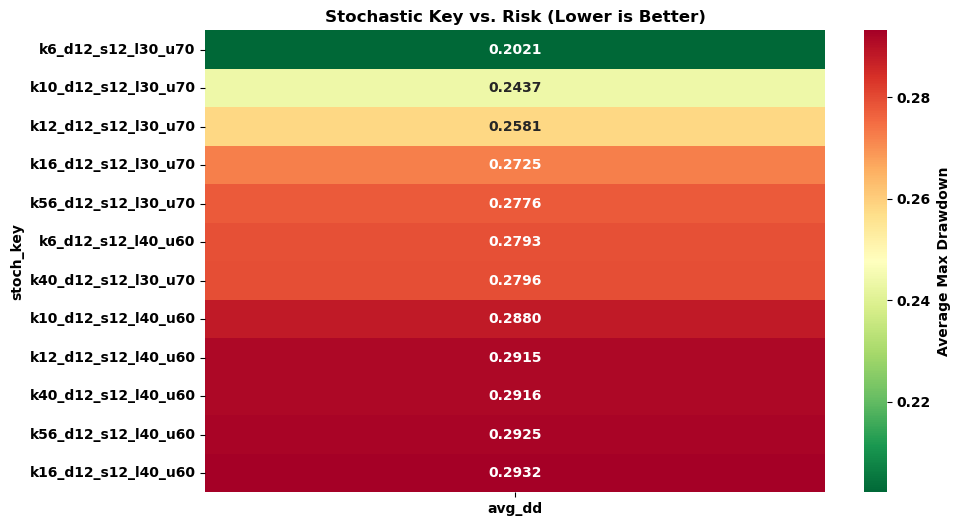


--- Stochastic Efficiency Table ---
          stoch_key   avg_dd     avg_bal  config_count
 k6_d12_s12_l30_u70 0.202144  134.149460        101760
k10_d12_s12_l30_u70 0.243675  157.384399        102320
k12_d12_s12_l30_u70 0.258115  146.925156        101440
k16_d12_s12_l30_u70 0.272546  157.671188        102400
k56_d12_s12_l30_u70 0.277590  330.438995        102400
 k6_d12_s12_l40_u60 0.279252  188.814255        102400
k40_d12_s12_l30_u70 0.279610  179.928711        102400
k10_d12_s12_l40_u60 0.287984  215.444275        102240
k12_d12_s12_l40_u60 0.291487  202.560791        100800
k40_d12_s12_l40_u60 0.291581  305.248779        102400
k56_d12_s12_l40_u60 0.292462 1274.286377        102400
k16_d12_s12_l40_u60 0.293229  197.503708        102400

STOCHASTIC VERIFICATION (Lookback: 1h)
               stoch_key  ma_int      avg_bal    med_dd  avg_trades  \
0                    OFF       1  6604.284180  0.302953      6947.6   
1                    OFF       2  1569.101807  0.302953      6217.

In [3]:
"""
Unified analysis script — crypto strategy master_metrics report
- Efficient (Polars) processing of large parquet
- Single consolidated output (console + JSON file)
- Prints provided Metadata at the top of the run

Usage:
  - point BASE_DIR to your data_lake
  - script finds latest Opt_Session_* and loads master_metrics.parquet
"""

from pathlib import Path
from typing import Dict, Any
import json
import polars as pl
import pandas as pd
import datetime
import seaborn as sns
import matplotlib.pyplot as plt

# -------------------------
# CONFIG / METADATA (user-provided)
# -------------------------
BASE_DIR = Path(r"C:\Users\Owner\airflow-trading\data_lake")  # adjust if needed
TARGET_FILENAME = "master_metrics.parquet"
OUTPUT_JSON = Path.cwd() / "master_metrics_analysis_report.json"

# user-supplied metadata (kept at top of output)
USER_METADATA = {
    "--- Metadata ---": None,
    "Total Rows in file": 1403943,
    "Columns": [
        "regime_id", "era_int", "side", "ma_int", "ma_reversion",
        "entry_lookback_units", "exit_window_h", "use_stochastic", "stoch_key",
        "SL", "TP", "total_pos", "win_pos", "balance", "max_drawdown"
    ],
}

# -------------------------
# Utilities
# -------------------------
def choose_session_dir(base_dir: Path) -> Path:
    """
    Lists all Opt_Session_* directories and asks user to choose one by number.
    1 = Latest, 2 = Second Latest, etc.
    """
    # Get all session directories, sorted descending (newest first)
    sessions = sorted(
        [d for d in base_dir.iterdir() if d.is_dir() and d.name.startswith("Opt_Session_")],
        reverse=True
    )
    
    if not sessions:
        raise FileNotFoundError(f"No Opt_Session_* directories found under {base_dir}")

    print("\n--- Available Optimization Sessions ---")
    for i, s in enumerate(sessions, 1):
        # We print the index and the folder name
        print(f"[{i}] {s.name}")

    while True:
        try:
            choice = input(f"\nSelect session number (1-{len(sessions)}) [Default 1 for Latest]: ").strip()
            if choice == "":
                return sessions[0]
            
            idx = int(choice) - 1
            if 0 <= idx < len(sessions):
                return sessions[idx]
            else:
                print(f"Please enter a number between 1 and {len(sessions)}.")
        except ValueError:
            print("Invalid input. Please enter a number.")

def sample_preview(df: pl.DataFrame, n: int = 10) -> pd.DataFrame:
    # small random preview converted to pandas for display
    sample = df.sample(n=n, with_replacement=False)
    return sample.to_pandas()

def to_serializable(df: pl.DataFrame, max_rows: int = 200) -> Any:
    # Convert to pandas then to records (cap rows)
    pdf = df.head(max_rows).to_pandas()
    return {"columns": pdf.columns.tolist(), "rows": pdf.to_dict(orient="records")}

# -------------------------
# Analysis functions (each returns serializable dict / small tables)
# -------------------------
def global_coverage(df: pl.DataFrame) -> Dict[str, Any]:
    total = df.height
    empty_rows = df.filter(pl.col("total_pos") == 0).height
    empty_pct = round((empty_rows / total) * 100, 4) if total else None
    return {
        "total_rows": total,
        "empty_rows_total_pos_eq_0": empty_rows,
        "empty_pct": empty_pct,
        "coverage_pct": None if empty_pct is None else round(100 - empty_pct, 4)
    }

def breakdown_by_config(df: pl.DataFrame, group_cols=None) -> pl.DataFrame:
    if group_cols is None:
        group_cols = ["entry_lookback_units", "ma_int", "use_stochastic"]
    # compute percent empty per config (use Polars aggregated df)
    out = (
        df.with_columns((pl.col("total_pos") == 0).alias("is_empty"))
          .groupby(group_cols)
          .agg([
              pl.count().alias("total_configs"),
              pl.col("is_empty").sum().cast(pl.UInt32).alias("empty_count"),
              (pl.col("is_empty").mean() * 100).alias("percent_empty")
          ])
          .sort("percent_empty", descending=True)
    )
    return out

def top_performers(df: pl.DataFrame, top_n: int = 20) -> pl.DataFrame:
    return (
        df.filter(pl.col("total_pos") > 0)
          .sort("balance", descending=True)
          .select([
              "balance", "total_pos", "max_drawdown", "ma_reversion", # Added here
              "entry_lookback_units", "ma_int", "SL", "TP", "use_stochastic"
          ])
          .head(top_n)
    )

def winning_dna(df: pl.DataFrame, pct: float = 0.01) -> pl.DataFrame:
    count = max(1, int(df.height * pct))
    return (
        df.sort("balance", descending=True)
          .head(count)
          .groupby("entry_lookback_units")
          .agg(pl.count().alias("occurrence_in_top_pct"))
          .sort("occurrence_in_top_pct", descending=True)
    )

def stable_winners(df: pl.DataFrame, max_dd: float = 0.08) -> pl.DataFrame:
    return (
        df.filter((pl.col("total_pos") > 0) & (pl.col("max_drawdown") < max_dd))
          .sort("balance", descending=True)
          .select([
              "balance", "max_drawdown", "ma_reversion", # Added here
              "total_pos", "win_pos", "entry_lookback_units", 
              "exit_window_h", "ma_int", "SL", "TP", "use_stochastic"
          ])
    )

def exit_impact(df: pl.DataFrame, stable_df: pl.DataFrame) -> pl.DataFrame:
    return (
        stable_df.groupby("exit_window_h")
                 .agg([
                     pl.col("balance").mean().alias("avg_balance"),
                     pl.col("total_pos").mean().alias("avg_trades"),
                     pl.count().alias("config_count")
                 ])
                 .sort("avg_balance", descending=True)
    )

def elite_configs(df: pl.DataFrame, max_dd: float = 0.08, min_trades: int = 150) -> pl.DataFrame:
    out = (
        df.filter((pl.col("max_drawdown") < max_dd) & (pl.col("total_pos") >= min_trades))
          .with_columns((pl.col("TP") / pl.col("SL")).alias("RR_Ratio"))
          .sort("balance", descending=True)
          .select([
              "balance", "total_pos", "max_drawdown", "RR_Ratio",
              "ma_int", "entry_lookback_units", "exit_window_h", "SL", "TP", "use_stochastic"
          ])
    )
    return out

def target_sl_tp_analysis(df: pl.DataFrame, sl: float = 0.1, tp: float = 1.0) -> Dict[str, Any]:
    target = df.filter((pl.col("SL") == sl) & (pl.col("TP") == tp))
    total_rows = target.height
    param_cols = ["ma_int", "ma_reversion", "entry_lookback_units", "exit_window_h", "use_stochastic", "SL", "TP"]
    unique_strategies = target.select(param_cols).n_unique()
    # performance comparison
    perf = (
        df.with_columns(
            pl.when((pl.col("SL") == sl) & (pl.col("TP") == tp))
            .then(pl.lit("Target (0.1/1.0)"))
            .otherwise(pl.lit("Other Settings"))
            .alias("group")
        )
        .groupby("group")
        .agg([
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("balance").median().alias("median_balance"),
            pl.col("total_pos").mean().alias("avg_trades"),
            pl.col("max_drawdown").mean().alias("avg_drawdown"),
            pl.count().alias("config_count")
        ])
    )
    return {
        "total_occurrences": total_rows,
        "unique_strategies": unique_strategies,
        "avg_appearances_per_strategy": (round(total_rows / unique_strategies, 2) if unique_strategies else None),
        "performance_summary": to_serializable(perf)
    }

def stochastic_impact(df: pl.DataFrame) -> Dict[str, Any]:
    overall = (
        df.groupby("use_stochastic")
          .agg([
              pl.col("balance").mean().alias("avg_balance"),
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.col("total_pos").mean().alias("avg_trades"),
              pl.count().alias("config_count")
          ])
    )
    elite = (
        df.filter((pl.col("max_drawdown") < 0.08) & (pl.col("total_pos") >= 150))
          .groupby("use_stochastic")
          .agg([
              pl.count().alias("count"),
              pl.col("balance").mean().alias("elite_avg_balance")
          ])
    )
    return {"overall": to_serializable(overall), "elite": to_serializable(elite)}

def rank_lookback_by_balance(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups by entry_lookback_units.
    Shows which eras each lookback appeared in and its global stats.
    """
    return (
        df.filter(pl.col("total_pos") > 0)
          .groupby("entry_lookback_units")
          .agg([
              # Count how many unique eras this lookback traded in
              pl.col("era_int").n_unique().alias("era_count"),
              
              # Create a sorted list of the actual era dates
              pl.col("era_int").unique().sort().alias("unique_eras"),
              
              # Performance metrics
              pl.col("balance").mean().alias("avg_balance"),
              pl.col("balance").median().alias("median_balance"),
              pl.col("max_drawdown").mean().alias("avg_drawdown"),
              
              # Total configurations tested for this lookback across all eras
              pl.count().alias("total_configs")
          ])
          .sort(["era_count", "avg_balance"], descending=[True, True])
    )

def rank_lookback_by_era(df: pl.DataFrame) -> pl.DataFrame:
    """
    Groups by both Era and Lookback to see if performance 
    is consistent across different time periods.
    """
    return (
        df.filter(pl.col("total_pos") > 0)
          .groupby(["era_int", "entry_lookback_units"])
          .agg([
              pl.col("balance").mean().alias("avg_balance"),
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.count().alias("num_configs")
          ])
          .sort(["era_int", "avg_balance"], descending=[False, True])
    )

def find_consistent_lookbacks(df: pl.DataFrame) -> pl.DataFrame:
    # 1. Get avg balance per lookback per era
    era_perf = (
        df.groupby(["entry_lookback_units", "era_int"])
          .agg(pl.col("balance").mean().alias("era_avg"))
    )
    
    # 2. Find lookbacks where the MINIMUM era average is > 100
    return (
        era_perf.groupby("entry_lookback_units")
                .agg([
                    pl.col("era_avg").min().alias("worst_era_avg"),
                    pl.col("era_avg").mean().alias("total_avg_balance"),
                    pl.col("era_avg").count().alias("era_count")
                ])
                .filter(pl.col("worst_era_avg") > 100)
                .sort("total_avg_balance", descending=True)
    )

def find_best_safe_configs(df: pl.DataFrame, max_dd: float = 0.05, min_trades: int = 50) -> pl.DataFrame:
    return (
        df.filter(
            (pl.col("max_drawdown") <= max_dd) & 
            (pl.col("total_pos") >= min_trades)
        )
        .sort("balance", descending=True)
        .select([
            "balance", 
            "max_drawdown", 
            "ma_reversion", 
            "stoch_key",      # <--- Added this line
            "total_pos", 
            "era_int",
            "entry_lookback_units", 
            "ma_int", 
            "SL", 
            "TP", 
            "use_stochastic"
        ])
        .head(20)
    )

def test_ma_reversion_impact(df: pl.DataFrame):
    """
    Compares 'Twins' (identical configs) where only ma_reversion changes.
    """
    dna_cols = [
        "side", "ma_int", "entry_lookback_units", "exit_window_h", 
        "use_stochastic", "stoch_key", "SL", "TP"
    ]
    
    # 1. Group by everything EXCEPT ma_reversion and pivot performance
    comparison = (
        df.groupby(dna_cols)
          .agg([
              pl.col("balance").filter(pl.col("ma_reversion") == True).mean().alias("bal_reversion"),
              pl.col("balance").filter(pl.col("ma_reversion") == False).mean().alias("bal_trend"),
              pl.col("total_pos").filter(pl.col("ma_reversion") == True).sum().alias("trades_reversion"),
              pl.col("total_pos").filter(pl.col("ma_reversion") == False).sum().alias("trades_trend")
          ])
          .drop_nulls() 
          .with_columns([
              (pl.col("bal_reversion") - pl.col("bal_trend")).alias("reversion_edge")
          ])
    )

    if comparison.is_empty():
        print("\n[!] No identical strategy 'twins' found to compare reversion vs trend.")
        return None

    # 2. Calculate Stats
    avg_edge = comparison.select(pl.col("reversion_edge").mean()).item()
    win_rate_rev = (comparison.filter(pl.col("reversion_edge") > 0).height / comparison.height) * 100
    
    print("\n" + "="*60)
    print("MA REVERSION VS TREND-FOLLOWING (PAIRED TEST)")
    print("="*60)
    print(f"Total Paired Strategies: {comparison.height}")
    print(f"Avg Balance Delta:      {avg_edge:+.4f} (Pos = Rev is better)")
    print(f"Reversion Win Rate:     {win_rate_rev:.1f}%")
    
    return comparison.sort("reversion_edge", descending=True)

def check_reversion_stability(df: pl.DataFrame):
    # Check if Reversion profit is consistent across different time periods (Eras)
    stability = (
        df.filter(pl.col("ma_reversion") == True)
          .groupby("era_int")
          .agg(pl.col("balance").mean().alias("avg_bal_reversion"))
          .sort("era_int")
    )
    print("\n--- Reversion Performance by Era ---")
    print(stability.to_pandas())



def generate_stochastic_heatmap(df: pl.DataFrame):
    """
    Creates a heatmap showing Average Max Drawdown per Stochastic Key.
    Lower values (darker/cooler) are the 'Safe Zones'.
    """
    # 1. Filter out OFF and aggregate
    stoch_data = (
        df.filter(pl.col("stoch_key") != "OFF")
          .groupby("stoch_key")
          .agg([
              pl.col("max_drawdown").mean().alias("avg_dd"),
              pl.col("balance").mean().alias("avg_bal"),
              pl.count().alias("config_count")
          ])
          .sort("avg_dd")
    )

    if stoch_data.is_empty():
        print("[!] No Stochastic data found to map.")
        return

    # 2. Prepare for Plotting
    plot_df = stoch_data.to_pandas().set_index("stoch_key")
    
    plt.figure(figsize=(10, 6))
    sns.heatmap(
        plot_df[["avg_dd"]], 
        annot=True, 
        cmap="RdYlGn_r", # Red = High DD, Green = Low DD
        fmt=".4f",
        cbar_kws={'label': 'Average Max Drawdown'}
    )
    plt.title("Stochastic Key vs. Risk (Lower is Better)")
    plt.show()

    print("\n--- Stochastic Efficiency Table ---")
    print(stoch_data.to_pandas().to_string(index=False))

    
def verify_stoch_dominance(df: pl.DataFrame):
    """
    Checks if l40_u60 is actually superior for the best Lookback/MA clusters
    or if it just got lucky in one specific Era.
    """
    # 1. Identify the 'Winning DNA' from your Top 20
    # (Lookback 1h, specific MA_int, etc.)
    winning_lookback = 1
    
    analysis = (
        df.filter(pl.col("entry_lookback_units") == winning_lookback)
          .groupby(["stoch_key", "ma_int"])
          .agg([
              pl.col("balance").mean().alias("avg_bal"),
              pl.col("max_drawdown").median().alias("med_dd"),
              pl.col("total_pos").mean().alias("avg_trades"),
              pl.count().alias("sample_size")
          ])
          .sort("avg_bal", descending=True)
    )
    
    print("\n" + "="*60)
    print(f"STOCHASTIC VERIFICATION (Lookback: {winning_lookback}h)")
    print("="*60)
    print(analysis.to_pandas())


# -------------------------
# MAIN: orchestrate a single consolidated report
# -------------------------
def main():
    start_ts = datetime.datetime.utcnow().isoformat() + "Z"

    # print user metadata header (keeps user-provided numbers visible)
    print("\n".join([f"{k}: {v}" for k, v in USER_METADATA.items() if v is not None]))
    print(f"Run timestamp (UTC): {start_ts}\n")

    # 1. Ask user for the session choice
    session_dir = choose_session_dir(BASE_DIR)
    path = session_dir / TARGET_FILENAME

    if not path.exists():
        raise FileNotFoundError(f"{TARGET_FILENAME} not found in {session_dir.name}")
    print(f"Loading file: {path}\n")
    df = pl.read_parquet(path)
    lookback_stats = rank_lookback_by_balance(df)

    safe_performers = find_best_safe_configs(df, max_dd=0.05, min_trades=50)

    # Confirm actual rows/columns (useful to compare with provided metadata)
    actual_rows = df.height
    actual_cols = df.columns

    # Build report dictionary
    report: Dict[str, Any] = {
        "generated_at_utc": start_ts,
        "user_metadata": USER_METADATA,
        "actual_rows": actual_rows,
        "actual_columns": actual_cols,
        "preview_sample": sample_preview(df, n=10).to_dict(orient="records"),
        "global_coverage": global_coverage(df),
        "breakdown_by_config_top_50": to_serializable(breakdown_by_config(df).head(50)),
        "top_performers_top_20": to_serializable(top_performers(df, top_n=20)),
        "winning_dna_top_1pct": to_serializable(winning_dna(df, pct=0.01)),
        "stable_winners_count_and_head": {
            "count": stable_winners(df).height,
            "head": to_serializable(stable_winners(df).head(20))
        },
        "exit_impact_on_stable": to_serializable(exit_impact(df, stable_winners(df))),
        "elite_configs": to_serializable(elite_configs(df)),
        "target_sl_tp_analysis": target_sl_tp_analysis(df, sl=0.1, tp=1.0),
        "stochastic_impact": stochastic_impact(df),
        "lookback_ranking": to_serializable(rank_lookback_by_balance(df))
    }

    # Save JSON report
    with OUTPUT_JSON.open("w", encoding="utf8") as fh:
        json.dump(report, fh, indent=2, default=str)

# --- Specialized Analysis Prints ---
    print("\n" + "="*60)
    print("TOP 20 CONFIGS: HIGHEST BALANCE WITH MAX DRAWDOWN <= 0.05")
    print("="*60)
    if not safe_performers.is_empty():
        print(safe_performers.to_pandas().to_string(index=False))
    else:
        print("No configurations found with DD <= 0.05 and trades >= 50.")

    print("\n" + "="*60)
    print("LOOKBACK SURVIVAL REPORT (Consistency across Eras)")
    print("="*60)
    pd.set_option('display.max_colwidth', None)
    print(lookback_stats.to_pandas().to_string(index=False))

    print(f"\nAnalysis Complete. JSON Report: {OUTPUT_JSON.name}")

    # --- ADD THIS CALL HERE ---
    reversion_results = test_ma_reversion_impact(df)
    
    # If you want to see the top 10 specific setups where reversion wins:
    if reversion_results is not None:
        print("\nTop 5 Setups where Reversion adds the most value:")
        print(reversion_results.head(5).to_pandas())

    check_reversion_stability(df)
    generate_stochastic_heatmap(df)
    verify_stoch_dominance(df)

if __name__ == "__main__":
    main()

In [2]:
print("=== LOOKBACK RANKING (Sorted by Avg Balance) ===")
lookback_rank = rank_lookback_by_balance(df)
print(lookback_rank.to_pandas().to_string(index=False))
print()

=== LOOKBACK RANKING (Sorted by Avg Balance) ===


NameError: name 'df' is not defined

In [22]:
# --- Print Lookback by Era ---
print("=== LOOKBACK RANKING BY ERA ===")
lookback_era_df = rank_lookback_by_era(df)
# We use to_pandas() just for the clean console alignment
print(lookback_era_df.to_pandas().to_string(index=False))
print("\n")

# --- Print Consistent Lookbacks (Survivors) ---
print("=== CONSISTENT LOOKBACKS (Profitable in ALL Eras) ===")
consistent_df = find_consistent_lookbacks(df)
if consistent_df.height > 0:
    print(consistent_df.to_pandas().to_string(index=False))
else:
    print(">>> No lookback was profitable across all eras. Risk is high.")
print("\n")

=== LOOKBACK RANKING BY ERA ===
 era_int  entry_lookback_h  avg_balance   avg_dd  num_configs
20240301                 1   101.344452 0.022522        19619
20240301                24    99.500000 0.005000         1715
20240301                 4    99.212212 0.043152         8918
20240301                20    99.002380 0.009975         1715
20240301                 8    98.617287 0.039248         6174
20240301                16    98.297913 0.017320         3430
20240301                12    96.969719 0.040536         3430
20240901                 1   108.306778 0.065152        27662
20240901               168   103.682922 0.019152        11502
20240901                 4   101.925621 0.032709        27325
20240901                72   101.411865 0.019602        11887
20240901                16   100.248528 0.022712        23992
20240901                12    99.962410 0.023299        26263
20240901                20    99.670349 0.022811        17207
20240901                24    99.54962

In [ ]:
try:
    # 1. Run the Safe Performer Analysis
    # We set max_drawdown to 0.05 as requested
    safe_performers = find_best_safe_configs(df, max_dd=0.05)

    print(f"\n--- TOP 20 CONFIGS (Max DD <= 5% | Min Trades 50) ---")
    if not safe_performers.is_empty():
        # Polars native print is safer for Notebooks
        with pl.Config(tbl_rows=20, fmt_str_lengths=50):
            print(safe_performers)
    else:
        print(">>> No configurations found meeting the 5% Drawdown constraint.")

    # 2. Summary of the Safe Winning DNA
    # This tells you which Lookbacks are 'Safe' lookbacks
    safe_dna = (
        df.filter(pl.col("max_drawdown") <= 0.05)
        .group_by("entry_lookback_h")
        .agg(pl.count().alias("safe_occurrence"))
        .sort("safe_occurrence", descending=True)
    )

    print("\n--- SAFE DNA: Lookbacks most likely to stay under 5% DD ---")
    print(safe_dna.head(5))

except Exception as e:
    print(f"Error: {e}")

Error: name 'df' is not defined


In [6]:
try:
    # 1. Define the quality filters
    # We want actual trades (total_pos > 0) and low drawdown
    stable_winners = (
        df.filter(
            (pl.col("total_pos") > 0) & 
            (pl.col("max_drawdown") < 0.05)
        )
        .sort("balance", descending=True)
        .select([
            "balance", 
            "max_drawdown",
            "total_pos", 
            "win_pos", 
            "entry_lookback_h",
            "exit_window_h", 
            "ma_int", 
            "SL", 
            "TP",
            "use_stochastic"
        ])
    )

    print(f"--- Top 20 Stable Winners (Max DD < 8%) ---")
    print(f"Found {stable_winners.height} configs matching these criteria out of {df.height} total.")
    print(stable_winners.head(20).to_pandas().to_string(index=False))

    # 2. Correlating Exit Window with Performance
    print("\n--- Impact of Exit Window on Average Balance (Stable Configs) ---")
    exit_impact = (
        stable_winners.groupby("exit_window_h")
        .agg([
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("total_pos").mean().alias("avg_trades"),
            pl.count().alias("config_count")
        ])
        .sort("avg_balance", descending=True)
    )
    print(exit_impact)

except Exception as e:
    print(f"Error: {e}")

--- Top 20 Stable Winners (Max DD < 8%) ---
Found 447867 configs matching these criteria out of 1403943 total.
   balance  max_drawdown  total_pos  win_pos  entry_lookback_h  exit_window_h  ma_int  SL  TP  use_stochastic
193.955643      0.039307         14        4                12            168       1 0.1 3.9           False
193.955643      0.039307         14        4                12            168       3 0.1 3.9           False
187.812881      0.024751         23        5                 4             72       2 0.1 3.1            True
187.812881      0.024751         23        5                 4            168       2 0.1 3.1            True
187.544449      0.039307         14        4                12            168       1 0.1 3.7           False
187.544449      0.039307         14        4                12            168       3 0.1 3.7           False
181.293518      0.039307         14        4                12            168       1 0.1 3.5           False
181.29351

In [10]:
try:
    # 1. Calculate Elite Configs with the RR_Ratio column
    elite_configs = (
        df.filter(
            (pl.col("max_drawdown") < 0.08) & 
            (pl.col("total_pos") >= 150)
        )
        .with_columns(
            # Calculate Risk/Reward Ratio: TP divided by SL
            (pl.col("TP") / pl.col("SL")).alias("RR_Ratio")
        )
        .sort("balance", descending=True)
        .select([
            "balance",
            "total_pos",
            "max_drawdown",
            "RR_Ratio", # Added for visibility
            "ma_int",
            "entry_lookback_h",
            "exit_window_h",
            "SL",
            "TP",
            "use_stochastic"
        ])
    )

    print(f"--- ISOLATED ELITE CONFIGS (Count: {elite_configs.height}) ---")
    print(elite_configs.to_pandas().to_string(index=False))

    # --- 2. DNA Analysis with RR_Ratio ---
    print("\n--- Common Traits of Elite Configs ---")
    print(f"Average RR Ratio: {elite_configs['RR_Ratio'].mean():.2f}")
    print(f"Average SL:       {elite_configs['SL'].mean():.4f}")
    print(f"Average TP:       {elite_configs['TP'].mean():.4f}")
    
    # Check if a specific RR ratio dominates (e.g., 10.0)
    rr_mode = elite_configs['RR_Ratio'].mode().to_list()
    print(f"Most common RR Ratio: {rr_mode}")

except Exception as e:
    print(f"Error: {e}")

--- ISOLATED ELITE CONFIGS (Count: 88) ---
   balance  total_pos  max_drawdown  RR_Ratio  ma_int  entry_lookback_h  exit_window_h  SL  TP  use_stochastic
191.034882        155      0.077069  6.600000       2                 1             72 0.5 3.3            True
191.034882        155      0.077069  6.600000       2                 1            168 0.5 3.3            True
177.471939        155      0.077069  6.200000       2                 1             72 0.5 3.1            True
177.471939        155      0.077069  6.200000       2                 1            168 0.5 3.1            True
173.958633        155      0.074067  4.714286       2                 1            168 0.7 3.3            True
170.481400        155      0.077069  5.800000       2                 1             72 0.5 2.9            True
170.481400        155      0.077069  5.800000       2                 1            168 0.5 2.9            True
169.102844        155      0.077069  4.714286       2                

In [21]:
# 1. Filter for your target settings
target_sl_tp = df.filter((pl.col("SL") == 0.1) & (pl.col("TP") == 1.0))

# 2. Count total occurrences vs unique parameter sets
total_rows = target_sl_tp.height
# We group by all parameters EXCEPT era/regime/metrics to find unique "strategies"
param_cols = ["ma_int", "ma_reversion", "entry_lookback_h", "exit_window_h", "use_stochastic", "SL", "TP"]
unique_strategies = target_sl_tp.select(param_cols).n_unique()

print(f"--- Uniqueness Check for SL=0.1 / TP=1.0 ---")
print(f"Total occurrences: {total_rows}")
print(f"Unique Strategies: {unique_strategies}")
print(f"Avg Appearances per Strategy: {total_rows / unique_strategies:.1f} eras")

# 3. Are they actually making more money than other SL/TP combos?
performance_comparison = (
    df.with_columns(
        pl.when((pl.col("SL") == 0.1) & (pl.col("TP") == 1.0))
        .then(pl.lit("Target (0.1/1.0)"))
        .otherwise(pl.lit("Other Settings"))
        .alias("group")
    )
    .groupby("group")
    .agg([
        pl.col("balance").mean().alias("avg_balance"),
        pl.col("balance").median().alias("median_balance"),
        pl.col("total_pos").mean().alias("avg_trades"),
        pl.col("max_drawdown").mean().alias("avg_drawdown"),
        pl.count().alias("config_count")
    ])
)

print("\n--- Performance vs. The Rest of the World ---")
print(performance_comparison)

--- Uniqueness Check for SL=0.1 / TP=1.0 ---
Total occurrences: 8904
Unique Strategies: 358
Avg Appearances per Strategy: 24.9 eras

--- Performance vs. The Rest of the World ---
shape: (2, 6)
┌──────────────────┬─────────────┬────────────────┬────────────┬──────────────┬──────────────┐
│ group            ┆ avg_balance ┆ median_balance ┆ avg_trades ┆ avg_drawdown ┆ config_count │
│ ---              ┆ ---         ┆ ---            ┆ ---        ┆ ---          ┆ ---          │
│ str              ┆ f32         ┆ f32            ┆ f64        ┆ f32          ┆ u32          │
╞══════════════════╪═════════════╪════════════════╪════════════╪══════════════╪══════════════╡
│ Other Settings   ┆ 99.534348   ┆ 100.0          ┆ 4.103754   ┆ 0.014087     ┆ 183531       │
│ Target (0.1/1.0) ┆ 101.771378  ┆ 100.0          ┆ 5.823338   ┆ 0.012934     ┆ 8904         │
└──────────────────┴─────────────┴────────────────┴────────────┴──────────────┴──────────────┘


In [32]:
try:
    # 1. Compare 'use_stochastic' groups across the whole dataset
    stoch_impact = (
        df.groupby("use_stochastic")
        .agg([
            pl.col("balance").mean().alias("avg_balance"),
            pl.col("max_drawdown").mean().alias("avg_dd"),
            pl.col("total_pos").mean().alias("avg_trades"),
            pl.count().alias("config_count")
        ])
    )

    print("--- Overall Stochastic Impact ---")
    print(stoch_impact)

    # 2. Check the "Elite" configurations specifically
    # (Drawdown < 8% and Trades > 150)
    elite_stoch = (
        df.filter((pl.col("max_drawdown") < 0.08) & (pl.col("total_pos") >= 150))
        .groupby("use_stochastic")
        .agg([
            pl.count().alias("count"),
            pl.col("balance").mean().alias("elite_avg_balance")
        ])
    )

    print("\n--- Stochastic Presence in Elite Configs ---")
    print(elite_stoch)

except Exception as e:
    print(f"Error: {e}")

--- Overall Stochastic Impact ---
shape: (2, 5)
┌────────────────┬─────────────┬──────────┬────────────┬──────────────┐
│ use_stochastic ┆ avg_balance ┆ avg_dd   ┆ avg_trades ┆ config_count │
│ ---            ┆ ---         ┆ ---      ┆ ---        ┆ ---          │
│ bool           ┆ f32         ┆ f32      ┆ f64        ┆ u32          │
╞════════════════╪═════════════╪══════════╪════════════╪══════════════╡
│ false          ┆ 97.376503   ┆ 0.069332 ┆ 25.199081  ┆ 6530         │
│ true           ┆ 99.674072   ┆ 0.012096 ┆ 3.445131   ┆ 185905       │
└────────────────┴─────────────┴──────────┴────────────┴──────────────┘

--- Stochastic Presence in Elite Configs ---
shape: (2, 3)
┌────────────────┬───────┬───────────────────┐
│ use_stochastic ┆ count ┆ elite_avg_balance │
│ ---            ┆ ---   ┆ ---               │
│ bool           ┆ u32   ┆ f32               │
╞════════════════╪═══════╪═══════════════════╡
│ true           ┆ 7     ┆ 195.950104        │
│ false          ┆ 6     ┆ 196.748

In [15]:
# MA Logic Accuracy Test

import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# --- 1. Find a popular SL/TP to compare fairly ---
# We read one row group to pick a baseline SL/TP
pf = pq.ParquetFile(MASTER_PATH)
sample_df = pf.read_row_group(0).to_pandas().head(100)
TEST_SL = sample_df['SL'].iloc[0]
TEST_TP = sample_df['TP'].iloc[0]

print(f"🧐 Comparing Trade Counts for SL: {TEST_SL}, TP: {TEST_TP}")

# --- 2. Scan multiple groups and sum trade counts ---
results = []
NUM_GROUPS_TO_SCAN = 30 # Scan more to find all MA combos
indices = np.linspace(0, pf.num_row_groups - 1, NUM_GROUPS_TO_SCAN, dtype=int)

for idx in indices:
    # Filter at the read level to save memory
    df = pf.read_row_group(idx).to_pandas()
    
    # Strictly filter for our test SL/TP pair
    mask = (df['SL'] == TEST_SL) & (df['TP'] == TEST_TP)
    df_sub = df[mask].copy()
    
    if df_sub.empty: continue

    # Apply ma_int logic
    if "ma_int" in df_sub.columns:
        df_sub["ma_int_calc"] = df_sub["ma_int"].fillna(0).astype(int)
    else:
        m5 = df_sub["use_ma_5min"].astype(int) if "use_ma_5min" in df_sub.columns else 0
        mh = df_sub["use_ma_hour"].astype(int) if "use_ma_hour" in df_sub.columns else 0
        md = df_sub["use_ma_day"].astype(int)  if "use_ma_day" in df_sub.columns else 0
        mw = df_sub["use_ma_week"].astype(int) if "use_ma_week" in df_sub.columns else 0
        df_sub["ma_int_calc"] = (m5 << 3) | (mh << 2) | (md << 1) | mw

    df_sub["ma_combo"] = df_sub["ma_int_calc"].apply(lambda x: format(int(x) & 0x0F, "04b"))
    
    # Store the sum of positions for each combo in this chunk
    chunk_res = df_sub.groupby("ma_combo")["total_pos"].sum().reset_index()
    results.append(chunk_res)

# Final Comparison
if results:
    final_comparison = pd.concat(results).groupby("ma_combo")["total_pos"].mean().sort_values(ascending=False).reset_index()
    print("\n--- Average Trades per Configuration (Higher = Less Filtered) ---")
    print(final_comparison)
    
    # Validation Logic
    top_combo = final_comparison.iloc[0]['ma_combo']
    if top_combo != '0000':
        print(f"\n🚨 WARNING: '{top_combo}' has more trades than '0000'. Filter logic might be inverted!")
    else:
        print(f"\n✅ SUCCESS: '0000' is the most permissive as expected.")
else:
    print("No data found for the selected SL/TP in these row groups.")

🧐 Comparing Trade Counts for SL: 20.0, TP: 800.0


AttributeError: 'str' object has no attribute 'shape'

In [8]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# --- 1. Setup ---
pf = pq.ParquetFile(MASTER_PATH)
# We'll pick a popular SL/TP again for consistency
sample = pf.read_row_group(0).to_pandas().head(1)
TEST_SL, TEST_TP = sample['SL'].iloc[0], sample['TP'].iloc[0]

print(f"🧐 Testing Lookback Filter Strength (SL: {TEST_SL}, TP: {TEST_TP})")

results = []
NUM_GROUPS_TO_SCAN = 40 # Increased scan to catch more lookback variations
indices = np.linspace(0, pf.num_row_groups - 1, NUM_GROUPS_TO_SCAN, dtype=int)

for idx in indices:
    df = pf.read_row_group(idx).to_pandas()
    
    # Filter for SL/TP and also ensure we only look at "No MA" (0000) 
    # to see ONLY the effect of the lookback filter
    if "ma_int" in df.columns:
        mask = (df['SL'] == TEST_SL) & (df['TP'] == TEST_TP) & (df['ma_int'] == 0)
    else:
        mask = (df['SL'] == TEST_SL) & (df['TP'] == TEST_TP)
        
    df_sub = df[mask].copy()
    if df_sub.empty: continue

    # Group by the lookback hours
    # If the column is missing, it implies 0 (no lookback filter)
    lb_col = 'entry_lookback_h' if 'entry_lookback_h' in df_sub.columns else None
    
    if lb_col:
        chunk_res = df_sub.groupby(lb_col)["total_pos"].mean().reset_index()
        results.append(chunk_res)

# --- 3. Final Comparison ---
if results:
    final_lb = pd.concat(results).groupby("entry_lookback_h")["total_pos"].mean().sort_index().reset_index()
    
    # Calculate % Reduction
    baseline = final_lb.iloc[0]['total_pos']
    final_lb['retention_pct'] = (final_lb['total_pos'] / baseline * 100).round(2)
    
    print("\n--- Lookback Filter Impact ---")
    print(final_lb)
    
    # Logic Check: Higher hours should generally have fewer positions
    if final_lb['total_pos'].is_monotonic_decreasing:
        print("\n✅ SUCCESS: Larger lookback windows are correctly filtering more trades.")
    else:
        print("\n⚠️ NOTE: Lookback isn't perfectly monotonic. This can happen if shorter lookbacks")
        print("hit 'choppy' periods while longer ones hit 'trending' periods in your sample.")
else:
    print("❌ No lookback data found in these row groups.")

🧐 Testing Lookback Filter Strength (SL: 20.0, TP: 800.0)

--- Lookback Filter Impact ---
   entry_lookback_h     total_pos  retention_pct
0                 0  47541.388889         100.00
1                40   2689.443850           5.66
2                48   3190.495798           6.71

⚠️ NOTE: Lookback isn't perfectly monotonic. This can happen if shorter lookbacks
hit 'choppy' periods while longer ones hit 'trending' periods in your sample.


In [9]:
import pandas as pd
import pyarrow.parquet as pq
import numpy as np

# --- Configuration ---
NUM_GROUPS_TO_SCAN = 50  # Increase for better accuracy, decrease for speed
TARGET_MA_INT = 0        # 0000 Combo
EPS = 1e-9

pf = pq.ParquetFile(MASTER_PATH)
total_rgs = pf.num_row_groups
indices = np.linspace(0, total_rgs - 1, NUM_GROUPS_TO_SCAN, dtype=int)

# Use only the columns needed for this specific math
cols = ['ma_int', 'total_pos', 'win_pos', 'SL', 'TP']

# Accumulators
total_trades = 0
total_wins = 0
sl_sum = 0
tp_sum = 0
configs_found = 0

print(f"🕵️ Analyzing '0000' Combo over {NUM_GROUPS_TO_SCAN} row groups...")

for idx in indices:
    df = pf.read_row_group(idx, columns=cols).to_pandas()
    
    # Filter for 0000 combo
    mask = (df['ma_int'].fillna(0).astype(int) == TARGET_MA_INT)
    df_sub = df[mask]
    
    if df_sub.empty:
        continue
        
    # Aggregate Stats for this chunk
    chunk_trades = df_sub['total_pos'].sum()
    chunk_wins = df_sub['win_pos'].sum()
    
    # Weight SL and TP by the number of trades in each config
    # (Because a config with 100 trades represents more "market reality" than one with 1)
    chunk_sl_weighted = (df_sub['SL'] * df_sub['total_pos']).sum()
    chunk_tp_weighted = (df_sub['TP'] * df_sub['total_pos']).sum()
    
    total_trades += chunk_trades
    total_wins += chunk_wins
    sl_sum += chunk_sl_weighted
    tp_sum += chunk_tp_weighted
    configs_found += len(df_sub)

# --- Final Calculations ---
if total_trades > 0:
    avg_win_rate = (total_wins / total_trades) * 100
    avg_sl = sl_sum / total_trades
    avg_tp = tp_sum / total_trades
    
    print(f"\n=== RESULTS FOR COMBO 0000 ===")
    print(f"Configs Scanned:   {configs_found:,}")
    print(f"Total Trades:      {total_trades:,.0f}")
    print(f"-------------------------------")
    print(f"Aggregate Win Rate: {avg_win_rate:.2f}%")
    print(f"Average SL:        {avg_sl:.1f} ticks")
    print(f"Average TP:        {avg_tp:.1f} ticks")
    print(f"Avg Risk:Reward:   1 : {avg_tp/avg_sl:.2f}")
    
    # Sanity Check
    if avg_win_rate < 35 and (avg_tp / avg_sl) > 1.5:
        print("\n✅ Strategy Profile: Trend Follower (Low Win Rate / High Reward)")
    elif avg_win_rate > 55:
        print("\n✅ Strategy Profile: Scalper (High Win Rate / Lower Reward)")
else:
    print("No 0000 trades found in the sampled groups.")

🕵️ Analyzing '0000' Combo over 50 row groups...

=== RESULTS FOR COMBO 0000 ===
Configs Scanned:   2,252,728
Total Trades:      47,007,427,168
-------------------------------
Aggregate Win Rate: 17.08%
Average SL:        400.1 ticks
Average TP:        6400.1 ticks
Avg Risk:Reward:   1 : 16.00

✅ Strategy Profile: Trend Follower (Low Win Rate / High Reward)


In [10]:
# --- Updated Configuration for Strings ---

import random

# --- 1. Get total row groups ---
pf = pq.ParquetFile(MASTER_PATH)
total_rgs = pf.num_row_groups

# --- 2. Pick random indices instead of a linear interval ---
# This ensures we don't fall into a 'sorting trap'
NUM_GROUPS_TO_SCAN = 50 
indices = random.sample(range(total_rgs), min(NUM_GROUPS_TO_SCAN, total_rgs))

print(f"🎲 Randomly sampling {len(indices)} groups to avoid sorting bias...")

cols = ['ma_int', 'total_pos', 'win_pos', 'SL', 'TP', 'side', 'exit_window_h']

# Accumulators
total_trades = 0
total_wins = 0
long_trades = 0
long_wins = 0
short_trades = 0
short_wins = 0
sl_sum = 0
tp_sum = 0
exit_window_sum = 0

print(f"🕵️ Analyzing '0000' Combo with Buy/Sell Strings...")

for idx in indices:
    df = pf.read_row_group(idx, columns=cols).to_pandas()
    
    # Filter for 0000 combo
    mask = (df['ma_int'].fillna(0).astype(int) == TARGET_MA_INT)
    df_sub = df[mask].copy()
    if df_sub.empty: continue
        
    # Global Aggregates
    total_trades += df_sub['total_pos'].sum()
    total_wins += df_sub['win_pos'].sum()
    
    # Side-Specific Aggregates (Strings: 'buy' / 'sell')
    buy_mask = df_sub['side'].str.lower() == 'buy'
    sell_mask = df_sub['side'].str.lower() == 'sell'
    
    long_trades += df_sub.loc[buy_mask, 'total_pos'].sum()
    long_wins += df_sub.loc[buy_mask, 'win_pos'].sum()
    
    short_trades += df_sub.loc[sell_mask, 'total_pos'].sum()
    short_wins += df_sub.loc[sell_mask, 'win_pos'].sum()

    # Weighted Averages
    sl_sum += (df_sub['SL'] * df_sub['total_pos']).sum()
    tp_sum += (df_sub['TP'] * df_sub['total_pos']).sum()
    exit_window_sum += (df_sub['exit_window_h'] * df_sub['total_pos']).sum()

# --- Final Output ---
if total_trades > 0:
    long_pct = (long_trades / total_trades) * 100
    short_pct = (short_trades / total_trades) * 100
    
    # Calculate separate win rates
    long_wr = (long_wins / long_trades * 100) if long_trades > 0 else 0
    short_wr = (short_wins / short_trades * 100) if short_trades > 0 else 0

    print(f"\n=== FINAL DEEP DIVE: COMBO 0000 (STRINGS) ===")
    print(f"Total Trades:       {total_trades:,.0f}")
    print(f"Overall Win Rate:   {total_wins/total_trades*100:.2f}%")
    print(f"--------------------------------------------")
    print(f"Avg SL:             {sl_sum/total_trades:.1f} ticks")
    print(f"Avg TP:             {tp_sum/total_trades:.1f} ticks (R:R 1:{(tp_sum/sl_sum):.1f})")
    print(f"Avg Exit Window:    {exit_window_sum/total_trades:.1f} hours")
    print(f"--------------------------------------------")
    print(f"SIDE PERFORMANCE:")
    print(f"LONG  (Buy):  {long_pct:4.1f}% of trades | Win Rate: {long_wr:.2f}%")
    print(f"SHORT (Sell): {short_pct:4.1f}% of trades | Win Rate: {short_wr:.2f}%")

🎲 Randomly sampling 50 groups to avoid sorting bias...
🕵️ Analyzing '0000' Combo with Buy/Sell Strings...

=== FINAL DEEP DIVE: COMBO 0000 (STRINGS) ===
Total Trades:       14,556,932,872
Overall Win Rate:   12.60%
--------------------------------------------
Avg SL:             400.0 ticks
Avg TP:             6400.0 ticks (R:R 1:16.0)
Avg Exit Window:    144.6 hours
--------------------------------------------
SIDE PERFORMANCE:
LONG  (Buy):  63.4% of trades | Win Rate: 1.59%
SHORT (Sell): 36.6% of trades | Win Rate: 31.66%


In [11]:
import random
import psutil
import pandas as pd
import numpy as np

# --- 1. Settings ---
NUM_GROUPS_TO_SCAN = 200 
pf = pq.ParquetFile(MASTER_PATH)
all_indices = list(range(pf.num_row_groups))
random.shuffle(all_indices)
selected_indices = all_indices[:NUM_GROUPS_TO_SCAN]

# Using a single dictionary for all stats: {(sl, tp): [total_trades, total_wins]}
sltp_stats = {}

# Side-specific accumulators
l_trades, l_wins = 0, 0
s_trades, s_wins = 0, 0

print(f"🔄 Deep Dive: Analyzing 0000 Combo & SL/TP Efficiency...")

for i, idx in enumerate(selected_indices):
    # Only load what is absolutely necessary for RAM efficiency
    df = pf.read_row_group(idx, columns=['ma_int', 'total_pos', 'win_pos', 'side', 'SL', 'TP']).to_pandas()
    
    # Filter for the 0000 combo (No MA filters)
    mask = (df['ma_int'].fillna(0).astype(int) == 0)
    df_sub = df[mask]
    if df_sub.empty: continue
    
    # --- Side Specific Logic ---
    buy_m = df_sub['side'].str.lower() == 'buy'
    l_trades += df_sub.loc[buy_m, 'total_pos'].sum()
    l_wins += df_sub.loc[buy_m, 'win_pos'].sum()
    
    sell_m = df_sub['side'].str.lower() == 'sell'
    s_trades += df_sub.loc[sell_m, 'total_pos'].sum()
    s_wins += df_sub.loc[sell_m, 'win_pos'].sum()

    # --- SL/TP Grouping ---
    # We aggregate total trades and wins for every unique SL/TP pair found in this chunk
    chunk_stats = df_sub.groupby(['SL', 'TP'])[['total_pos', 'win_pos']].sum()
    
    for (sl, tp), row in chunk_stats.iterrows():
        if (sl, tp) not in sltp_stats:
            sltp_stats[(sl, tp)] = [0, 0]
        sltp_stats[(sl, tp)][0] += row['total_pos'] # Total Trades
        sltp_stats[(sl, tp)][1] += row['win_pos']   # Total Wins

    if (i + 1) % 50 == 0:
        mem = psutil.virtual_memory().percent
        print(f"   [{i+1}/{NUM_GROUPS_TO_SCAN}] RAM: {mem}%")

# --- 2. Final Analysis & Table Construction ---
print(f"\n=== THE STABLE TRUTH (Target: 0000) ===")
print(f"Final Long Win Rate:  {(l_wins/l_trades*100):.2f}%" if l_trades > 0 else "Long: N/A")
print(f"Final Short Win Rate: {(s_wins/s_trades*100):.2f}%" if s_trades > 0 else "Short: N/A")

print(f"\n=== DETAILED SL/TP PERFORMANCE (Sorted by Expected Value) ===")
print(f"{'SL':>5} | {'TP':>6} | {'Win Rate':>10} | {'Total Trades':>15} | {'Exp. Value'}")
print("-" * 70)

# Calculate EV for each pair and sort
# EV = (Win% * TP) - (Loss% * SL)
results_list = []
for (sl, tp), (pos, win) in sltp_stats.items():
    wr = (win / pos) if pos > 0 else 0
    ev = (wr * tp) - ((1 - wr) * sl)
    results_list.append({
        'sl': sl, 'tp': tp, 'wr': wr * 100, 'pos': pos, 'ev': ev
    })

# Sort by Expected Value (highest first)
results_list = sorted(results_list, key=lambda x: x['ev'], reverse=True)

for r in results_list[:20]: # Show top 20 pairs
    print(f"{r['sl']:5.0f} | {r['tp']:6.0f} | {r['wr']:9.2f}% | {r['pos']:15,.0f} | {r['ev']:8.2f}")

🔄 Deep Dive: Analyzing 0000 Combo & SL/TP Efficiency...
   [100/200] RAM: 76.6%

=== THE STABLE TRUTH (Target: 0000) ===
Final Long Win Rate:  2.41%
Final Short Win Rate: 32.26%

=== DETAILED SL/TP PERFORMANCE (Sorted by Expected Value) ===
   SL |     TP |   Win Rate |    Total Trades | Exp. Value
----------------------------------------------------------------------
   20 |  12000 |     10.23% |       5,526,161 |  1209.14
   20 |  11960 |     10.24% |       5,526,161 |  1206.30
   20 |  11920 |     10.25% |       5,526,161 |  1203.67
   20 |  11880 |     10.26% |       5,526,161 |  1200.97
   20 |  11840 |     10.28% |       5,526,161 |  1198.97
   20 |  11800 |     10.29% |       5,526,161 |  1196.71
   20 |  11760 |     10.31% |       5,526,161 |  1194.28
   20 |  11720 |     10.32% |       5,526,161 |  1191.72
   20 |  11680 |     10.33% |       5,526,161 |  1189.13
   20 |  11640 |     10.35% |       5,526,161 |  1186.69
   20 |  11600 |     10.36% |       5,526,161 |  1184.12
  

In [16]:
import pyarrow.parquet as pq

file_path = r"C:\Users\Owner\Backtest_results\BTC\Opt_Session_20260302_185231_01\master_results.parquet"

try:
    # 1. Open the file handle
    parquet_file = pq.ParquetFile(file_path)
    
    # 2. Extract Shape
    num_rows = parquet_file.metadata.num_rows
    num_cols = parquet_file.metadata.num_columns
    
    print(f"--- MASTER FILE SHAPE ---")
    print(f"Rows:    {num_rows:,}")
    print(f"Columns: {num_cols}")
    print(f"Shape:   ({num_rows}, {num_cols})")

    # 3. Check Row Groups (The "Chunks" your scanner uses)
    num_groups = parquet_file.num_row_groups
    print(f"\n--- STORAGE STRUCTURE ---")
    print(f"Number of Row Groups: {num_groups}")
    print(f"Avg Rows per Group:    {num_rows // num_groups:,}")

except Exception as e:
    print(f"Error: {e}")

# Master Columns: ['index', 'ma_combo', 'configs_tested', 'total_trades_found', 'win_rate_pct', 'agg_profit_factor', 'mean_EV_row']

--- MASTER FILE SHAPE ---
Rows:    801,187,200
Columns: 11
Shape:   (801187200, 11)

--- STORAGE STRUCTURE ---
Number of Row Groups: 1022
Avg Rows per Group:    783,940
